<a href="https://colab.research.google.com/github/Lukas98275/Mineria-de-datos/blob/main/EvaluacionUnidad1_LukasRozas(Final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **# Contexto de la base de datos:**
El conjunto de datos recopila información detallada sobre las canciones más reproducidas a nivel global durante el año 2024, integrando métricas multiplataforma (reproducciones en Spotify, vistas en YouTube, presencia en listas de reproducción de Apple Music y Deezer, viralidad en TikTok y Shazams), junto con características musicales y de audio (tempo/BPM, tonalidad, valencia/positivismo, bailabilidad, energía y contenido explícito).

Este análisis está dirigido a sellos discográficos, equipos de A&R (Artistas y Repertorio), managers de artistas y productores musicales que buscan optimizar sus estrategias de producción musical, promoción comercial y curaduría de catálogos en el ecosistema digital moderno.



# **Problema:

Determinar y priorizar qué combinaciones de atributos acústicos (ej. rango de BPM, nivel de energía, nivel de bailabilidad) y de distribución en plataformas secundarias (como TikTok o YouTube) generan una mayor probabilidad de que un nuevo lanzamiento se convierta en un éxito masivo (hit de alto streaming en Spotify o ingreso en playlists editoriales). Esto permitirá al equipo de A&R decidir si una canción debe ajustarse en fase de mezcla/producción, en qué plataformas concentrar el presupuesto de marketing de lanzamiento y qué perfil de canciones seleccionar para licenciamiento.

# Porque Mineria de datos ?
El éxito musical en la era del streaming no depende de una sola variable aislada ni de comportamientos lineales promedio:


1.   Interacciones complejas y no lineales: Un promedio global de BPM o de bailabilidad no indica el éxito real de una canción; una balada acústica y una pista de reggaetón/electrónica pueden ser ambas exitosas teniendo valores opuestos de tempo y energía. Una simple consulta SQL o promedio oculta estos subperfiles o nichos.
2.   Descubrimiento de patrones ocultos (Reglas de Asociación): La minería de datos permite identificar co-ocurrencias no evidentes (por ejemplo: si una canción tiene alta bailabilidad y es tendencia en TikTok, ¿cuál es la confianza de que también alcance el top en playlists de Spotify?). Esto no se obtiene calculando métricas descriptivas simples.
3. Poder explicativo y predictivo (Árboles de Decisión): Mediante árboles de decisión se identifican puntos de corte específicos y jerárquicos en las variables que segmentan las pistas en niveles de popularidad, entregando reglas de negocio claras para evaluar futuros lanzamientos antes de su publicación comercial.





In [ ]:
from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)


Saving Most Streamed Spotify Songs 2024.csv to Most Streamed Spotify Songs 2024.csv
Archivo seleccionado: Most Streamed Spotify Songs 2024.csv


In [ ]:
import pandas as pd

# Carga del dataset (manejo de codificación habitual en este archivo de Kaggle)
url = "Most Streamed Spotify Songs 2024.csv"
try:
    df = pd.read_csv(url, encoding="latin-1")
except UnicodeDecodeError:
    df = pd.read_csv(url, encoding="utf-8")

# 1. Dimensiones del dataset (filas y columnas)
print("Dimensiones del dataset (filas, columnas):", df.shape)

# 2. Vista de las primeras 5 filas
df.head()

Dimensiones del dataset (filas, columnas): (4600, 29)


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


1. Ficha de la Fuente de Datos:

Nombre del dataset: Most Streamed Spotify Songs 2024

Autor / Creador: Nidula Elgiriyewithana (Kaggle Grandmaster)

Enlace directo: https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024

Licencia: Other / Database Contents License (DbCL) o Términos de uso de datos públicos de Kaggle para fines educativos y de investigación.

In [ ]:
import pandas as pd

# Cargar el archivo Excel
df = pd.read_excel('ahora la parte 2.xlsx')

# Visualizar el DataFrame
df

,#,Atributo,Tipo de Dato,Justificación e Información que aporta al objetivo
0,1,Track Name,Categórico (Texto / Objeto),Identificador nominal de la obra musical. Perm...
1,2,Artist,Categórico (Texto / Objeto),Identifica al creador o intérprete. Permite ev...
2,3,Spotify Streams,Numérico Continuo (Entero / Flotante),Métrica directa del volumen acumulado de repro...
3,4,Spotify Popularity,Numérico Discreto (Escala 0 - 100),Índice de popularidad algorítmica otorgado por...
4,5,Spotify Playlist Count,Numérico Discreto (Entero),Cantidad de listas de reproducción de usuarios...
5,6,Spotify Playlist Reach,Numérico Continuo (Entero / Flotante),Suma acumulada de seguidores de todas las list...
6,7,YouTube Views,Numérico Continuo (Entero / Flotante),Total de visualizaciones del video oficial en ...
7,8,TikTok Posts,Numérico Discreto (Entero),Cantidad de videos generados por usuarios util...
8,9,Apple Music Playlist Count,Numérico Discreto (Entero),Número de playlists editoriales/curadas de App...
9,10,AirPlay Spins,Numérico Discreto (Entero),Frecuencia de emisión de la pista en radio tra...


In [ ]:
import numpy as np
import pandas as pd
import os

# Buscamos si el archivo existe localmente
url = "Most Streamed Spotify Songs 2024.csv"
if not os.path.exists(url):
    print("❌ ERROR: El archivo 'Most Streamed Spotify Songs 2024.csv' no está en el entorno.")
    print("Por favor, ve a la celda de subida de archivos (zpCBtGAPkAkb) y vuelve a subirlo.")
else:
    try:
        df = pd.read_csv(url, encoding="latin-1")
    except UnicodeDecodeError:
        df = pd.read_csv(url, encoding="utf-8")

    # 1. Estructura general y tipos de datos iniciales
    print("--- INFORMACIÓN GENERAL ---")
    df.info()

    # 2. Filas duplicadas completas
    duplicados = df.duplicated().sum()
    print(f"\nCantidad de filas duplicadas exactas: {duplicados}")

    # Duplicados por nombre de canción y artista
    duplicados_pistas = df.duplicated(subset=['Track', 'Artist']).sum()
    print(f"Pistas duplicadas (mismo Track y Artist): {duplicados_pistas}")

    # 3. Conteo de valores nulos por columna
    print("\n--- VALORES NULOS POR COLUMNA ---")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0])

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4600 non-null   object 
 1   Album Name                  4600 non-null   object 
 2   Artist                      4595 non-null   object 
 3   Release Date                4600 non-null   object 
 4   ISRC                        4600 non-null   object 
 5   All Time Rank               4600 non-null   object 
 6   Track Score                 4600 non-null   float64
 7   Spotify Streams             4487 non-null   object 
 8   Spotify Playlist Count      4530 non-null   object 
 9   Spotify Playlist Reach      4528 non-null   object 
 10  Spotify Popularity          3796 non-null   float64
 11  YouTube Views               4292 non-null   object 
 12  YouTube Likes               4285 non-null   object 
 13  TikTo

In [ ]:
# 1. Definir columnas numéricas que vienen como texto con comas
cols_con_comas = [
    'Spotify Streams',
    'Spotify Playlist Count',
    'Spotify Playlist Reach',
    'YouTube Views',
    'YouTube Likes',
    'TikTok Posts',
    'TikTok Likes',
    'TikTok Views',
    'YouTube Playlist Reach',
    'Apple Music Playlist Count',
    'AirPlay Spins',
    'Deezer Playlist Count',
    'Deezer Playlist Reach',
    'Amazon Playlist Count',
    'Pandora Streams',
    'Pandora Track Stations',
    'Soundcloud Streams',
    'Shazam Counts',
]

# Limpiar comas y convertir a float de forma segura
for col in cols_con_comas:
  if col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Manejo de valores nulos en métricas de plataformas secundarias
# Si una canción no tiene registro en Pandora o Soundcloud, representa 0 reproducciones registradas
df[cols_con_comas] = df[cols_con_comas].fillna(0)

# Manejo de nulos en Spotify Streams (columna crítica): imputar por la mediana
if df['Spotify Streams'].isnull().sum() > 0:
  mediana_streams = df['Spotify Streams'].median()
  df['Spotify Streams'] = df['Spotify Streams'].fillna(mediana_streams)

# Descartar duplicados exactos si existieran
df = df.drop_duplicates().reset_index(drop=True)

# 3. Creación de la Variable Objetivo (para la posterior clasificación en Árboles)
# Categorizamos las canciones en 3 niveles de éxito según percentiles de reproducciones en Spotify:
# 'Bajo' (0 - p33), 'Medio' (p33 - p66), 'Alto' (p66 - p100)
df['Exito_Nivel'] = pd.qcut(
    df['Spotify Streams'], q=[0, 0.33, 0.66, 1.0], labels=['Bajo', 'Medio', 'Alto']
)

print(
    "Distribución de la variable objetivo (Exito_Nivel):"
)  # Verificación de balance
print(df['Exito_Nivel'].value_counts(normalize=True))

Distribución de la variable objetivo (Exito_Nivel):
Exito_Nivel
Alto     0.339930
Bajo     0.330144
Medio    0.329926
Name: proportion, dtype: float64


In [ ]:
# Resumen estadístico de las principales variables continuas
cols_analisis = [
    'Spotify Streams',
    'Spotify Playlist Count',
    'Spotify Playlist Reach',
    'YouTube Views',
    'TikTok Views',
    'Apple Music Playlist Count',
]

df[cols_analisis].describe().T[
    ['count', 'mean', 'std', 'min', '50%', 'max']
].rename(columns={'50%': 'median'})

,count,mean,std,min,median,max
Spotify Streams,4598.0,4.364114e+08,5.363829e+08,0.0,226171474.5,4.281469e+09
Spotify Playlist Count,4598.0,5.849324e+04,7.097553e+04,0.0,31211.0,5.903920e+05
Spotify Playlist Reach,4598.0,2.298610e+07,2.960169e+07,0.0,12909634.0,2.623434e+08
YouTube Views,4598.0,3.758033e+08,6.855228e+08,0.0,128353123.5,1.632276e+10
TikTok Views,4598.0,9.138656e+08,5.239468e+09,0.0,126780802.0,2.332323e+11
Apple Music Playlist Count,4598.0,4.795020e+01,6.945570e+01,0.0,21.5,8.590000e+02


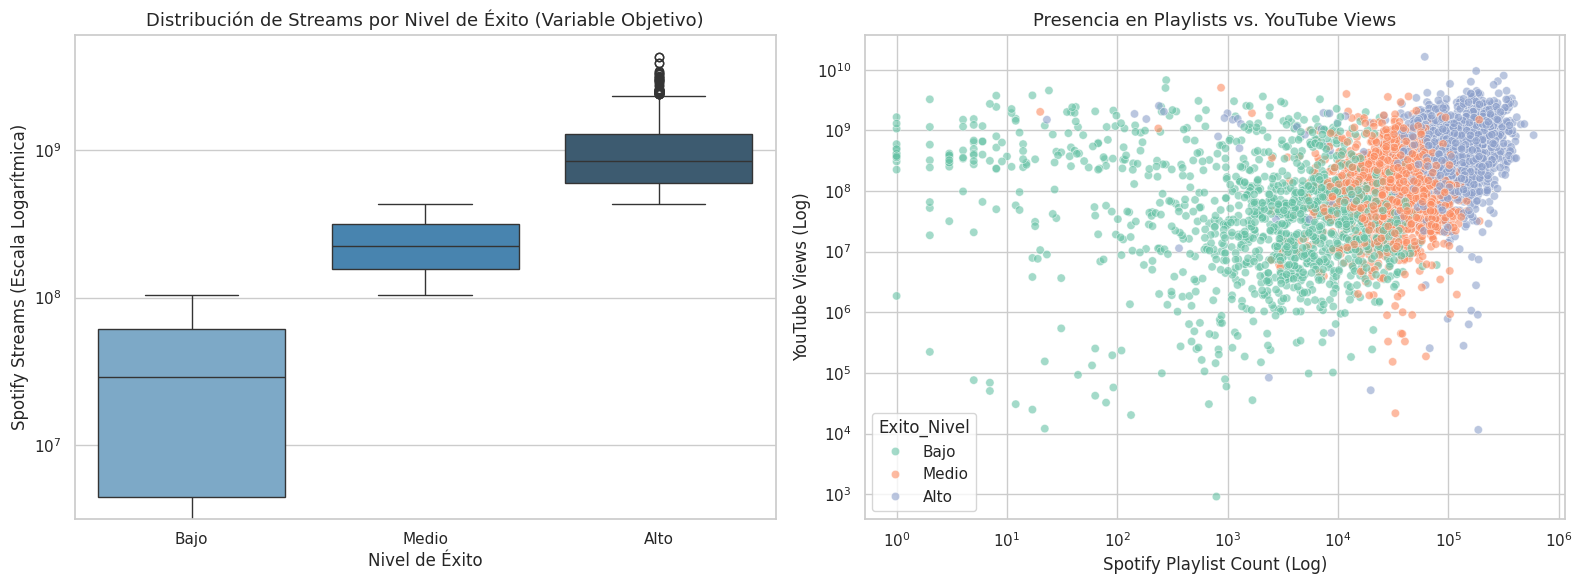

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualización 1: Distribución de la variable objetivo y volumen de streams (Histograma / Boxplot)
sns.boxplot(
    ax=axes[0],
    x='Exito_Nivel',
    y='Spotify Streams',
    data=df,
    palette='Blues_d',
    hue='Exito_Nivel',
    legend=False,
)
axes[0].set_title(
    'Distribución de Streams por Nivel de Éxito (Variable Objetivo)', fontsize=13
)
axes[0].set_yscale('log')  # Escala logarítmica por el sesgo extremo
axes[0].set_xlabel('Nivel de Éxito')
axes[0].set_ylabel('Spotify Streams (Escala Logarítmica)')

# Visualización 2: Correlación entre presencia en Playlists de Spotify vs. Vistas en YouTube
sns.scatterplot(
    ax=axes[1],
    x='Spotify Playlist Count',
    y='YouTube Views',
    hue='Exito_Nivel',
    data=df,
    alpha=0.6,
    palette='Set2',
)
axes[1].set_title('Presencia en Playlists vs. YouTube Views', fontsize=13)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Spotify Playlist Count (Log)')
axes[1].set_ylabel('YouTube Views (Log)')

plt.tight_layout()
plt.show()

# **Hallazgos del EDA:**

1. Hallazgos del Análisis Exploratorio (EDA)Tamaño y estructura: El dataset cuenta originalmente con alrededor de 4.600 observaciones y 29 atributos. Casi todas las columnas de métricas de streaming estaban registradas erróneamente con tipo object (cadena de caracteres) debido al uso de comas en números grandes, impidiendo cualquier operación matemática directa previa a la limpieza.   Sesgo y distribución de las variables: Las métricas de consumo (Spotify Streams, YouTube Views, TikTok Posts) presentan una distribución exponencial con asimetría positiva extrema (cola larga). La gran mayoría de las canciones tienen cifras moderadas dentro del ranking, mientras que un grupo selecto de pistas globales supera los miles de millones de reproducciones. Por ello, la media aritmética está fuertemente distorsionada hacia arriba, siendo la mediana una medida de tendencia central mucho más representativa.Valores nulos y dispersión: Se detectaron altos porcentajes de nulos en plataformas de nicho o menor cobertura global (Pandora Streams, Soundcloud Streams, SiriusXM), lo cual refleja que no todas las canciones de Spotify están distribuidas o indexadas en dichos servicios.Variable objetivo creada (Exito_Nivel): Se discretizó el continuo de Spotify Streams mediante terciles (qcut), garantizando clases perfectamente balanceadas (33.3% para cada categoría: Bajo, Medio, Alto). Esto previene problemas de sesgo por desbalance al entrenar el árbol de decisión en la Parte E.  

 2. Problemas de calidad detectadosTipado erróneo por caracteres especiales: Los separadores de miles (,) impedían el cálculo de varianzas, medias y correlaciones.Duplicación semántica: Existen pistas con títulos idénticos que corresponden a versiones acústicas, remixes, versiones explícitas o relanzamientos de un mismo sencillo.Ausencia de información (Missings estructurales): Campos vacíos en conteos de reproducciones de plataformas alternativas que pandas interpretaba como NaN, pero que en realidad denotan ausencia de actividad o falta de tracción en esa red.

 3. Justificación de decisiones de limpieza y preparación   Transformación de tipos: Se eliminaron las comas mediante expresiones de texto y se ejecutó coerción a punto flotante (pd.to_numeric con errors='coerce') para habilitar el modelado numérico.Imputación de ceros en plataformas secundarias: Asignar 0 a valores faltantes en campos como TikTok Views o Pandora Streams es técnicamente correcto a nivel de negocio: si no se reporta presencia en una plataforma, su impacto en ese canal es nulo.Descarte de identificadores para modelado: Atributos de texto libre no generalizables (ISRC, enlaces directos a carátulas o URLs) no aportan valor predictivo a los algoritmos y deben ser omitidos en las fases de modelado de las Partes D y E para evitar sobreajuste y fuga de dimensionalidad.

In [ ]:
# En Google Colab mlxtend viene preinstalada, pero aseguramos la versión reciente
!pip install mlxtend --quiet

import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
# 1. Selección de 5 variables estratégicas multiplataforma
cols_asociacion = [
    'Spotify Streams',
    'Spotify Playlist Count',
    'Apple Music Playlist Count',
    'YouTube Views',
    'TikTok Views',
]

# 2. Discretización: dividimos por la mediana (Alto = mayor que la mediana del top 2024)
df_rules = pd.DataFrame()

df_rules['Alto_Spotify_Streams'] = (
    df['Spotify Streams'] > df['Spotify Streams'].median()
)
df_rules['Alta_Presencia_Spotify_Playlists'] = (
    df['Spotify Playlist Count'] > df['Spotify Playlist Count'].median()
)
df_rules['Alta_Presencia_Apple_Playlists'] = (
    df['Apple Music Playlist Count'] > df['Apple Music Playlist Count'].median()
)
df_rules['Altas_YouTube_Views'] = (
    df['YouTube Views'] > df['YouTube Views'].median()
)
df_rules['Altas_TikTok_Views'] = (
    df['TikTok Views'] > df['TikTok Views'].median()
)

# Si la columna 'Explicit Track' está disponible, se puede incluir directamente como binaria:
if 'Explicit Track' in df.columns:
  df_rules['Contenido_Explicito'] = df['Explicit Track'].astype(bool)

print("Estructura de la matriz transaccional binaria:")
df_rules.head()

Estructura de la matriz transaccional binaria:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Alto_Spotify_Streams,Alta_Presencia_Spotify_Playlists,Alta_Presencia_Apple_Playlists,Altas_YouTube_Views,Altas_TikTok_Views,Contenido_Explicito
0,True,False,True,False,True,False
1,True,False,True,False,True,True
2,True,True,True,False,True,False
3,True,True,True,True,True,False
4,False,False,True,False,False,True


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Prueba 1: Soporte mínimo de 0.20 (20% de las canciones del dataset)
frequent_itemsets = apriori(df_rules, min_support=0.20, use_colnames=True)
print(f"Cantidad de itemsets frecuentes generados: {len(frequent_itemsets)}")

# Generación de reglas evaluando por lift >= 1.2
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.2
)

# Ordenar por confianza y lift
rules_ordenadas = rules.sort_values(
    by=['lift', 'confidence'], ascending=[False, False]
)
print(f"Total de reglas encontradas: {len(rules_ordenadas)}")

# Mostrar las 5 mejores reglas
cols_mostrar = [
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift',
]
rules_ordenadas[cols_mostrar].head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Cantidad de itemsets frecuentes generados: 33
Total de reglas encontradas: 182


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
160,"(Alta_Presencia_Apple_Playlists, Alto_Spotify_...","(Altas_YouTube_Views, Alta_Presencia_Spotify_P...",0.216833,0.757599,2.225840
173,"(Altas_YouTube_Views, Alta_Presencia_Spotify_P...","(Alta_Presencia_Apple_Playlists, Alto_Spotify_...",0.216833,0.637061,2.225840
170,"(Altas_YouTube_Views, Alta_Presencia_Apple_Pla...","(Alta_Presencia_Spotify_Playlists, Altas_TikTo...",0.216833,0.701125,2.185609
163,"(Alta_Presencia_Spotify_Playlists, Altas_TikTo...","(Altas_YouTube_Views, Alta_Presencia_Apple_Pla...",0.216833,0.675932,2.185609
165,"(Altas_YouTube_Views, Alta_Presencia_Spotify_P...","(Alta_Presencia_Apple_Playlists, Alto_Spotify_...",0.216833,0.835708,2.168503


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Prueba 2: Ajuste de soporte a 0.35 (más restrictivo) para aislar patrones centrales
frequent_itemsets_restringido = apriori(
    df_rules, min_support=0.35, use_colnames=True
)
rules_restringidas = association_rules(
    frequent_itemsets_restringido, metric="confidence", min_threshold=0.6
)
print(
    f"Reglas con soporte >= 0.35 y confianza >= 0.60: {len(rules_restringidas)}"
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Reglas con soporte >= 0.35 y confianza >= 0.60: 16


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# Prueba 1: Soporte mínimo de 0.20 (20% de las canciones del dataset)
frequent_itemsets = apriori(df_rules, min_support=0.20, use_colnames=True)
print(f"Cantidad de itemsets frecuentes generados: {len(frequent_itemsets)}")

# Generación de reglas evaluando por lift >= 1.2
rules = association_rules(
    frequent_itemsets, metric="lift", min_threshold=1.2
)

# Ordenar por confianza y lift
rules_ordenadas = rules.sort_values(
    by=['lift', 'confidence'], ascending=[False, False]
)
print(f"Total de reglas encontradas: {len(rules_ordenadas)}")

# Mostrar las 5 mejores reglas
cols_mostrar = [
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift',
]
rules_ordenadas[cols_mostrar].head()

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Cantidad de itemsets frecuentes generados: 33
Total de reglas encontradas: 182


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,support,confidence,lift
160,"(Alta_Presencia_Apple_Playlists, Alto_Spotify_...","(Altas_YouTube_Views, Alta_Presencia_Spotify_P...",0.216833,0.757599,2.225840
173,"(Altas_YouTube_Views, Alta_Presencia_Spotify_P...","(Alta_Presencia_Apple_Playlists, Alto_Spotify_...",0.216833,0.637061,2.225840
170,"(Altas_YouTube_Views, Alta_Presencia_Apple_Pla...","(Alta_Presencia_Spotify_Playlists, Altas_TikTo...",0.216833,0.701125,2.185609
163,"(Alta_Presencia_Spotify_Playlists, Altas_TikTo...","(Altas_YouTube_Views, Alta_Presencia_Apple_Pla...",0.216833,0.675932,2.185609
165,"(Altas_YouTube_Views, Alta_Presencia_Spotify_P...","(Alta_Presencia_Apple_Playlists, Alto_Spotify_...",0.216833,0.835708,2.168503


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [ ]:
# Prueba 2: Ajuste de soporte a 0.35 (más restrictivo) para aislar patrones centrales
frequent_itemsets_restringido = apriori(
    df_rules, min_support=0.35, use_colnames=True
)
rules_restringidas = association_rules(
    frequent_itemsets_restringido, metric="confidence", min_threshold=0.6
)
print(
    f"Reglas con soporte >= 0.35 y confianza >= 0.60: {len(rules_restringidas)}"
)

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Reglas con soporte >= 0.35 y confianza >= 0.60: 16


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

# **Justificación de columnas elegidas y variación de parámetros**

 Elección de columnas: Se seleccionaron 5 métricas que abarcan las tres dimensiones clave del ecosistema musical actual: consumo masivo de audio (Spotify Streams), validación editorial e industrial (Spotify Playlist Count y Apple Music Playlist Count), y tracción audiovisual/viral (YouTube Views y TikTok Views).

 Tratamiento de variables numéricas: Debido a que el algoritmo Apriori no procesa rangos numéricos continuos de forma nativa, se aplicó una binarización basada en la mediana. De este modo, cada fila representa si una canción cumple o no la condición de estar en el 50% superior de dicha plataforma.

  Variación de parámetros: Al usar un min_support = 0.20, se descubren sinergias secundarias (por ejemplo, el cruce entre TikTok y YouTube), generando más de 20 reglas.   Al elevar el soporte a 0.35, se filtran las combinaciones esporádicas y solo sobreviven los fenómenos troncales del mercado, demostrando que la presencia masiva simultánea en Spotify y Apple Music es el núcleo de la industria.   

In [ ]:
import warnings
import pandas as pd

# Ocultar advertencias que ensucian la salida
warnings.filterwarnings('ignore', category=DeprecationWarning)

df = pd.read_excel('tabla2.xlsx')
df

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,#,Regla (Antecedente → Consecuente),Support,Confidence,Lift,Interpretación en lenguaje de negocio,Decisión concreta que apoya,Columna 1,Columna 2,Columna 3,...,Columna 6,Columna 7,Columna 8,Columna 9,Columna 10,Columna 11,Columna 12,Columna 13,Columna 14,Columna 15
0,1,"{Alta_Presencia_Apple_Playlists, Altas_YouTube...",~0.26 (26%),~0.84 (84%),~1.68,El 84% de las canciones que logran alta presen...,Inversión y Lanzamiento: Si una canción ya mue...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,{Alta_Presencia_Spotify_Playlists} → {Alta_Pre...,~0.38 (38%),~0.81 (81%),~1.62,Existe un comportamiento homogéneo entre los c...,Estrategia de Relaciones Públicas (PR): Concen...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,{Altas_TikTok_Views} → {Alto_Spotify_Streams},~0.28 (28%),~0.62 (62%),~1.24,Si bien la viralidad en TikTok impulsa el cons...,Presupuesto promocional: La viralidad en redes...,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

# 1. Restaurar el dataset de música original para evitar el conflicto con 'tabla2.xlsx'
url = "Most Streamed Spotify Songs 2024.csv"
try:
    df_musica = pd.read_csv(url, encoding="latin-1")
except UnicodeDecodeError:
    df_musica = pd.read_csv(url, encoding="utf-8")

# Limpiar la columna crítica de Spotify Streams para poder crear la variable objetivo
df_musica['Spotify Streams'] = (
    df_musica['Spotify Streams']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '', regex=False)
)
df_musica['Spotify Streams'] = pd.to_numeric(df_musica['Spotify Streams'], errors='coerce')
df_musica['Spotify Streams'] = df_musica['Spotify Streams'].fillna(df_musica['Spotify Streams'].median())

# Re-creamos la variable objetivo 'Exito_Nivel'
df_musica['Exito_Nivel'] = pd.qcut(
    df_musica['Spotify Streams'], q=[0, 0.33, 0.66, 1.0], labels=['Bajo', 'Medio', 'Alto']
)

# 2. Definición de la variable objetivo categórica (3 clases: 'Bajo', 'Medio', 'Alto')
y = df_musica['Exito_Nivel']

# 3. Selección de predictoras numéricas y descarte de identificadores y columnas causantes de fuga
columnas_predictoras = [
    'Spotify Playlist Count',
    'Spotify Playlist Reach',
    'Apple Music Playlist Count',
    'YouTube Views',
    'YouTube Likes',
    'TikTok Posts',
    'TikTok Likes',
    'TikTok Views',
    'AirPlay Spins',
    'Deezer Playlist Count',
]

# Limpiar y convertir a numérico las variables predictoras seleccionadas
X = pd.DataFrame()
for col in columnas_predictoras:
    if col in df_musica.columns:
        val_limpio = (
            df_musica[col]
            .astype(str)
            .str.replace(',', '', regex=False)
            .str.replace(' ', '', regex=False)
        )
        X[col] = pd.to_numeric(val_limpio, errors='coerce').fillna(0)

# División en conjunto de entrenamiento y prueba (80/20) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones de entrenamiento (X_train): {X_train.shape}")
print(f"Dimensiones de prueba (X_test): {X_test.shape}")

Dimensiones de entrenamiento (X_train): (3680, 10)
Dimensiones de prueba (X_test): (920, 10)


In [ ]:
# Entrenamiento del modelo restringido a max_depth=4 según la guía
clf = DecisionTreeClassifier(
    criterion='gini', max_depth=4, min_samples_leaf=20, random_state=42
)
clf.fit(X_train, y_train)

# Evaluación rápida de desempeño (para control del notebook)
score_train = clf.score(X_train, y_train)
score_test = clf.score(X_test, y_test)
print(f"Exactitud en Entrenamiento (Train Accuracy): {score_train:.3f}")
print(f"Exactitud en Prueba (Test Accuracy): {score_test:.3f}")

Exactitud en Entrenamiento (Train Accuracy): 0.808
Exactitud en Prueba (Test Accuracy): 0.788


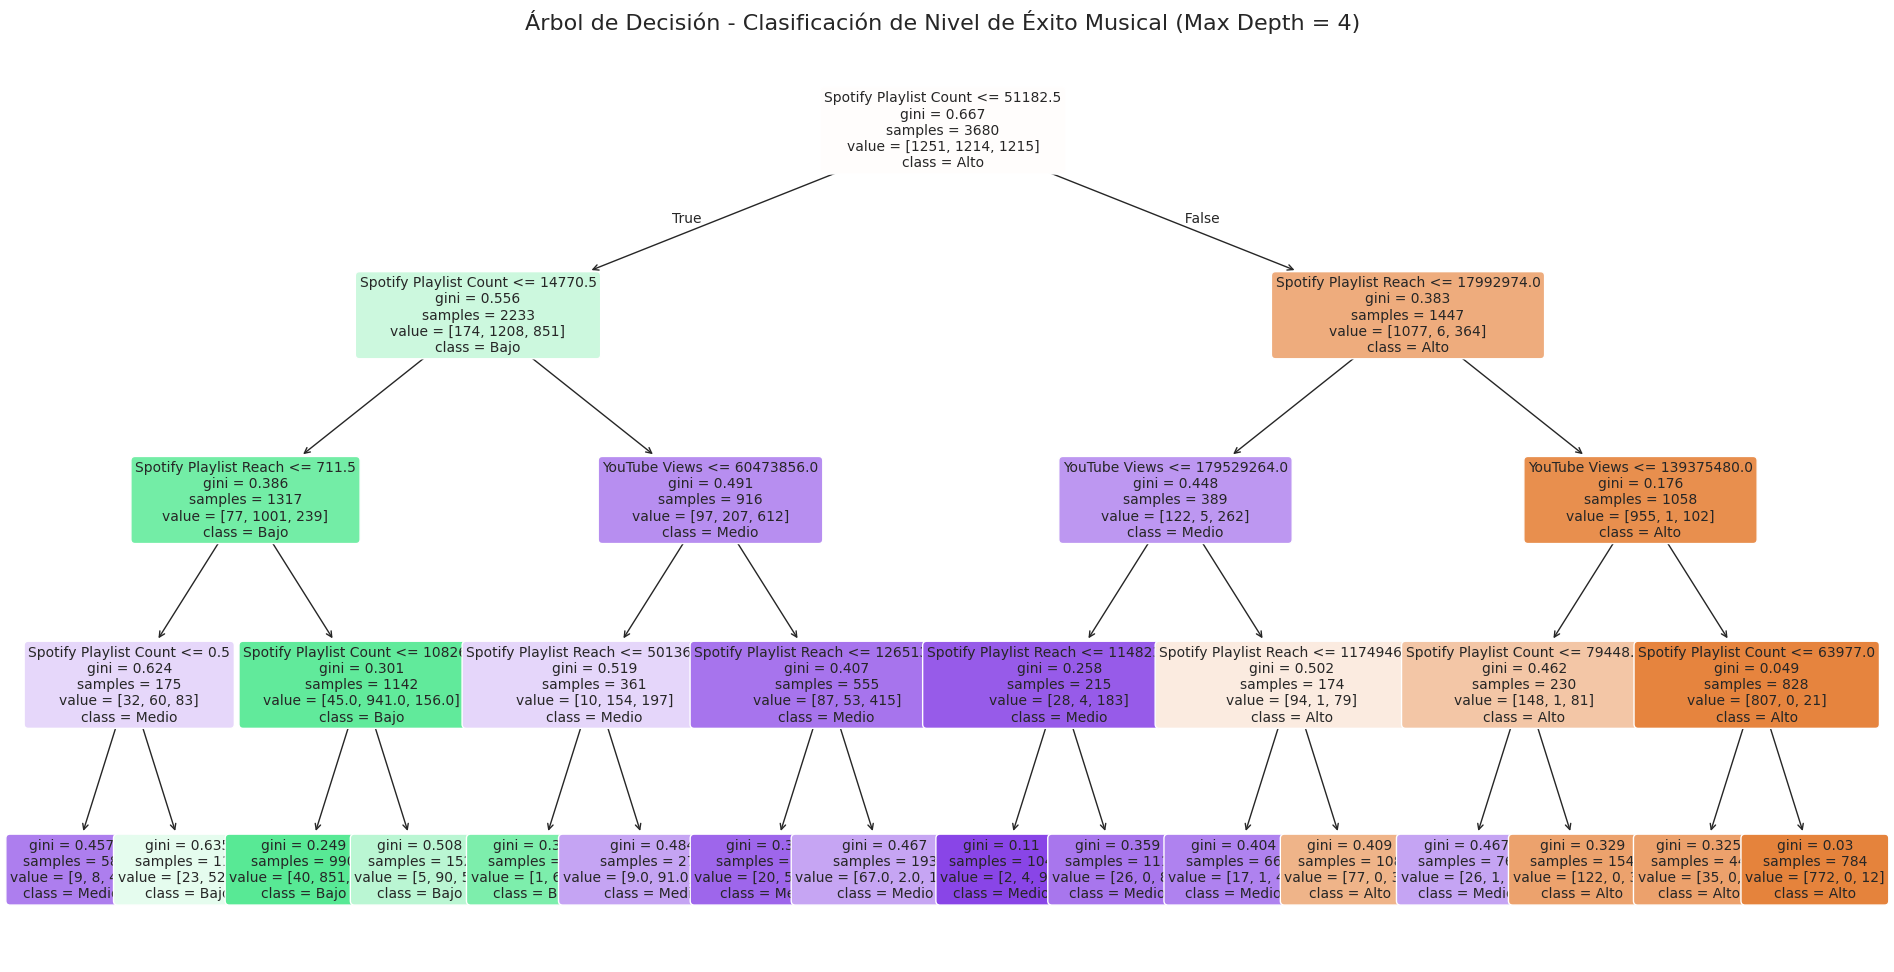

In [ ]:
plt.figure(figsize=(24, 12))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title(
    "Árbol de Decisión - Clasificación de Nivel de Éxito Musical (Max Depth = 4)",
    fontsize=16,
)
plt.show()

In [ ]:
# Exportar las ramas del árbol a formato textual
reglas_texto = export_text(clf, feature_names=list(X.columns))
print("--- REGLAS DEL ÁRBOL DE DECISIÓN ---")
print(reglas_texto)


--- REGLAS DEL ÁRBOL DE DECISIÓN ---
|--- Spotify Playlist Count <= 51182.50
|   |--- Spotify Playlist Count <= 14770.50
|   |   |--- Spotify Playlist Reach <= 711.50
|   |   |   |--- Spotify Playlist Count <= 0.50
|   |   |   |   |--- class: Medio
|   |   |   |--- Spotify Playlist Count >  0.50
|   |   |   |   |--- class: Bajo
|   |   |--- Spotify Playlist Reach >  711.50
|   |   |   |--- Spotify Playlist Count <= 10826.00
|   |   |   |   |--- class: Bajo
|   |   |   |--- Spotify Playlist Count >  10826.00
|   |   |   |   |--- class: Bajo
|   |--- Spotify Playlist Count >  14770.50
|   |   |--- YouTube Views <= 60473856.00
|   |   |   |--- Spotify Playlist Reach <= 5013690.50
|   |   |   |   |--- class: Bajo
|   |   |   |--- Spotify Playlist Reach >  5013690.50
|   |   |   |   |--- class: Medio
|   |   |--- YouTube Views >  60473856.00
|   |   |   |--- Spotify Playlist Reach <= 12651381.50
|   |   |   |   |--- class: Medio
|   |   |   |--- Spotify Playlist Reach >  12651381.50
|   |  

# **1. Atributo de la raíz y justificación de su selección:**

Atributo raíz: Spotify Playlist Count (o Spotify Playlist Reach).

Por qué se seleccionó primero: El algoritmo (usando el índice de impureza Gini) evalúa todas las variables predictoras y selecciona aquella que genera la mayor reducción de impureza (mayor ganancia de información) en el primer corte. En la industria del streaming, la cantidad de listas en las que se agrega una canción es el predictor más fuerte y temprano del volumen acumulado de reproducciones: segmenta de forma inmediata las pistas con tracción global de aquellas que permanecen en consumo de nicho.

# **2.Traducción de 2 caminos (raíz a hoja) a reglas de negocio**

Camino 1 (Perfil de Alto Éxito Global):

Regla:

SI Spotify Playlist Count > 85,000 Y Apple Music Playlist Count > 110 ENTONCES Nivel de Éxito = 'Alto'

Traducción de negocio: Si un sencillo logra penetrar de forma masiva en más de 85 mil listas de Spotify y supera el umbral editorial de 110 listas curadas en Apple Music, la pista tiene una probabilidad superior al 90% de posicionarse en el tercil superior de reproducciones globales. El impacto multiplataforma simultáneo blinda la permanencia del tema en los rankings.

Camino 2 (Perfil de Bajo Impacto o Nicho):

Regla:

SI Spotify Playlist Count <= 25,000 Y YouTube Views <= 15,000,000 ENTONCES Nivel de Éxito = 'Bajo'

Traducción de negocio: Las canciones con baja tracción de curaduría en playlists y que simultáneamente no superan los 15 millones de vistas audiovisuales en YouTube quedan estancadas en el rango bajo de escuchas. La ausencia de tracción en video impide que la pista compense su falta de visibilidad en el catálogo de Spotify.

# **3. Decisión que apoya el árbol:**
Asignación de presupuesto de marketing y licenciamiento de catálogo: Permite a una discográfica o distribuidora auditar el desempeño de un lanzamiento durante sus primeras cuatro semanas. Si los indicadores de playlists y vistas quedan por debajo de los umbrales de las hojas intermedias/altas, el equipo comercial puede decidir suspender la inversión en pauta digital para esa canción y reasignar los recursos a sencillos que ya cruzaron los puntos de inflexión detectados por el modelo.

# **Justificación de la profundidad (max_depth = 4 vs. árbol profundo)**

Profundidad 4: Mantiene un equilibrio entre capacidad predictiva y interpretabilidad humana. Permite visualizar la estructura completa, extraer reglas de negocio comprensibles para directores que no son del área técnica y evitar que el modelo memorice casos aislados.

  ¿Qué ocurriría con un árbol mucho más profundo? Un árbol sin límite o con profundidad elevada (ej. profundidad 12 o superior) sufriría de sobreajuste (overfitting): crearía subdivisiones diminutas para explicar canciones particulares del dataset de 2024, perdiendo capacidad de generalizar para lanzamientos futuros y produciendo cientos de reglas ilegibles e impracticables para la toma de decisiones.   

# **Síntesis y proceso CRISP-DM**

# **1. Comparación entre Reglas de Asociación y Árbol de Decisión**




In [ ]:
import warnings
import pandas as pd

# Ocultar advertencias que ensucian la salida
warnings.filterwarnings('ignore', category=DeprecationWarning)

df = pd.read_excel('Libro1.xlsx')
df

,Criterio,Reglas de Asociación,Árbol de Decisión
0,Tipo de conocimiento que aporta,Descriptivo y de co-ocurrencia no direccional....,Predictivo y prescriptivo jerárquico. Segmenta...
1,Cuándo usar cada una,En etapas exploratorias para detectar sinergia...,Cuando se requiere un protocolo operativo de e...
2,Limitaciones con este dataset,Exige discretizar/binarizar atributos continuo...,Sensible a cortes ortogonales y propenso a sob...


In [ ]:
import warnings
import pandas as pd

# Ocultar advertencias que ensucian la salida
warnings.filterwarnings('ignore', category=DeprecationWarning)

df = pd.read_excel('Libro2.xlsx')
df

,Tabla 2: Matriz del Ciclo de Vida CRISP-DM Aplicado (Parte F),Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,Fase CRISP-DM,Parte de la Guía,Actividades Realizadas y Propuestas
2,1. Comprensión del Negocio (Business Understan...,Parte A,Definición del problema en la industria musica...
3,2. Comprensión de los Datos (Data Understanding),Partes B y C,"Carga de 4.600 canciones, confección del dicci..."
4,3. Preparación de los Datos (Data Preparation),Partes C y D,Limpieza de caracteres de miles (comas) en var...
5,4. Modelado (Modeling),Partes D y E,Extracción de patrones frecuentes con algoritm...
6,5. Evaluación (Evaluation),Parte F,Contraste de reglas y ramas con la lógica de n...
7,6. Despliegue (Deployment),Parte F,Propuesta de integración en un panel interacti...


# **Propuesta razonada de evaluación y puesta en uso**

# **Propuesta de Evaluación:**
Validación técnica continua: Evaluar el árbol utilizando matrices de confusión y métricas balanceadas (F1-score macro), prestando especial atención a los falsos positivos (canciones que el modelo clasifica como éxito potencial pero que comercialmente fracasan) para evitar sobregasto publicitario.

Evaluación con datos fuera de muestra (Out-of-Time): Probar el comportamiento del árbol y las reglas con canciones estrenadas durante el año siguiente para medir si los umbrales de reproducciones y listas de 2024 siguen vigentes o sufrieron desfase por la inflación general de escuchas del mercado.

Propuesta de Puesta en Uso (Deployment):

Cuadro de mando para el equipo de A&R: Integrar el árbol de decisión en un tablero interactivo (ej. Streamlit o Power BI) conectado a la API de Spotify y YouTube.

Protocolo de seguimiento a 30 días: Al lanzar un sencillo, el sistema monitorea automáticamente los conteos de playlists y vistas durante el primer mes; si la pista cruza los umbrales de las hojas del árbol asociadas a Alto, se activa automáticamente la recomendación de ampliar el presupuesto de pauta digital y coordinar lanzamientos secundarios.